# 01 — Load & clean the Porto Taxi data**Goal:** load the real Porto Taxi `train.csv`, filter out bad rows, take a manageable random sample spread across the year, and save the result to Google Drive so the next notebooks can reuse it.**Inputs:** `train.csv` placed at `/content/train.csv` (downloaded from Kaggle).**Outputs (saved to Drive):**- `porto_clean.csv` — cleaned sample of ~50k trips with the `POLYLINE` column kept.- `fig_overlay_real.png` — overlay plot of real trajectories for the slides.---## 1. Setup — mount Drive and define paths

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!mkdir -p /content/drive/MyDrive/ADM_project
!cp /content/train.csv /content/drive/MyDrive/ADM_project/train.csv
!ls -lh /content/drive/MyDrive/ADM_project/

In [2]:
# 2. download via Kaggle API directly to /content
!pip install -q kaggle

# IF you have your kaggle.json file: upload it once, then:
# from google.colab import files; files.upload()   # pick kaggle.json
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d crailtap/taxi-trajectory -p /content
!unzip -o /content/taxi-trajectory.zip -d /content
!ls -lh /content/train.csv

Dataset URL: https://www.kaggle.com/datasets/crailtap/taxi-trajectory
License(s): unknown
100% 515M/515M [00:28<00:00, 18.6MB/s]

Archive:  /content/taxi-trajectory.zip
  inflating: /content/train.csv      
-rw-r--r-- 1 root root 1.9G Sep 29  2019 /content/train.csv


In [6]:
# 3. copy to Drive ONCE so future sessions skip the download
!cp /content/train.csv /content/drive/MyDrive/ADM_project/train.csv

In [3]:
#do that in next runs
!cp /content/drive/MyDrive/ADM_project/train.csv /content/train.csv

In [7]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Source file (downloaded from Kaggle, currently in /content)
RAW_PATH = "/content/train.csv"

# Where to save the cleaned sample
PROJECT_DIR = "/content/drive/MyDrive/ADM_project"
os.makedirs(PROJECT_DIR, exist_ok=True)

CLEAN_PATH = os.path.join(PROJECT_DIR, "porto_clean.csv")
FIG_PATH   = os.path.join(PROJECT_DIR, "fig_overlay_real.png")

print("Raw file:", RAW_PATH, "exists:", os.path.exists(RAW_PATH))
print("Project folder:", PROJECT_DIR)

Raw file: /content/train.csv exists: True
Project folder: /content/drive/MyDrive/ADM_project


---## 2. Look at the data at full scale (metadata only)Before we touch the heavy `POLYLINE` column, read just the cheap metadata columns to get a global picture of the dataset — that tells us the real distributions of trip type, day type, missing data, and the time range.

In [8]:
meta = pd.read_csv(
    RAW_PATH,
    usecols=["CALL_TYPE", "TAXI_ID", "TIMESTAMP", "DAY_TYPE", "MISSING_DATA"]
)
print("Total trips:", len(meta))
print("Unique taxis:", meta["TAXI_ID"].nunique())
print()
print("CALL_TYPE distribution (% of trips):")
print((meta["CALL_TYPE"].value_counts(normalize=True) * 100).round(2))
print()
print("DAY_TYPE distribution:")
print(meta["DAY_TYPE"].value_counts())
print()
print("MISSING_DATA = True count:", meta["MISSING_DATA"].sum())
print()
date_range = pd.to_datetime(meta["TIMESTAMP"], unit="s").agg(["min", "max"])
print("Date range:")
print(date_range)

Total trips: 1710670
Unique taxis: 448

CALL_TYPE distribution (% of trips):
CALL_TYPE
B    47.81
C    30.87
A    21.32
Name: proportion, dtype: float64

DAY_TYPE distribution:
DAY_TYPE
A    1710670
Name: count, dtype: int64

MISSING_DATA = True count: 10

Date range:
min   2013-07-01 00:00:53
max   2014-06-30 23:59:56
Name: TIMESTAMP, dtype: datetime64[ns]


**What to write down for the report:** the exact numbers above — total trips, number of taxis, the year covered, the proportion of each trip type. These are facts about the dataset that should appear on the dataset slide and in the report.

---## 3. Read a random sample including polylinesWe can't load all 1.7 M polylines into memory at once (Colab's free 12 GB RAM would crash). Instead, sample every 30th row — since the file is sorted by timestamp, this gives ~57k trips evenly spread across the full year.

In [9]:
df = pd.read_csv(
    RAW_PATH,
    skiprows=lambda i: i > 0 and i % 30 != 0,
)
print("Sampled rows:", len(df))
print("Columns:", list(df.columns))
df.head(3)

Sampled rows: 57022
Columns: ['TRIP_ID', 'CALL_TYPE', 'ORIGIN_CALL', 'ORIGIN_STAND', 'TAXI_ID', 'TIMESTAMP', 'DAY_TYPE', 'MISSING_DATA', 'POLYLINE']


,TRIP_ID,CALL_TYPE,ORIGIN_CALL,ORIGIN_STAND,TAXI_ID,TIMESTAMP,DAY_TYPE,MISSING_DATA,POLYLINE
0,1372640555620000235,C,NaN,NaN,20000235,1372640555,A,False,"[[-8.611065,41.149431],[-8.611209,41.149368],[..."
1,1372641749620000571,B,NaN,34.0,20000571,1372641749,A,False,"[[-8.615556,41.140692],[-8.615304,41.140818],[..."
2,1372642553620000167,C,NaN,NaN,20000167,1372642553,A,False,"[[-8.674119,41.153868],[-8.673939,41.154336],[..."


---## 4. Filter out bad rowsWe drop four kinds of trips:1. **MISSING_DATA = True** — GPS had gaps.2. **Empty polylines** — `POLYLINE == "[]"`. These are rows the recording produced but no points were captured.3. **Very short trips** (< 5 points = under 1 minute). Not enough signal.4. **Very long trips** (> 360 points = over 90 minutes). Almost certainly drivers who forgot to end the trip ("meter left on") — these dominate naive anomaly scores but are uninteresting.We report the count dropped at each step so we can write it in the report.

In [10]:
n0 = len(df)
print(f"Start:                       {n0:>7d} trips")

# Step 1: drop MISSING_DATA = True
df = df[~df["MISSING_DATA"]].copy()
print(f"After MISSING_DATA = False:  {len(df):>7d}  (-{n0 - len(df)})")

# Step 2: drop empty polylines (the literal string '[]')
n1 = len(df)
df = df[df["POLYLINE"] != "[]"].copy()
print(f"After non-empty polyline:    {len(df):>7d}  (-{n1 - len(df)})")

# Step 3 & 4: parse polylines and filter on point count
df["pts"] = df["POLYLINE"].apply(json.loads)
df["n_points"] = df["pts"].apply(len)

n2 = len(df)
df = df[(df["n_points"] >= 5) & (df["n_points"] <= 360)].copy()
print(f"After 5 <= n_points <= 360:  {len(df):>7d}  (-{n2 - len(df)})")

print()
print(f"Final cleaned sample:        {len(df):>7d} trips")

Start:                         57022 trips
After MISSING_DATA = False:    57022  (-0)
After non-empty polyline:      56823  (-199)
After 5 <= n_points <= 360:    55160  (-1663)

Final cleaned sample:          55160 trips


---## 5. Quick exploratory plots — sanity checkThree small plots so we know the data looks reasonable before saving:- **Trip length distribution** — how many points per trip.- **Trips per month** — coverage across the year.- **Overlay of real Porto trajectories** — replaces the synthetic figure for the slides.

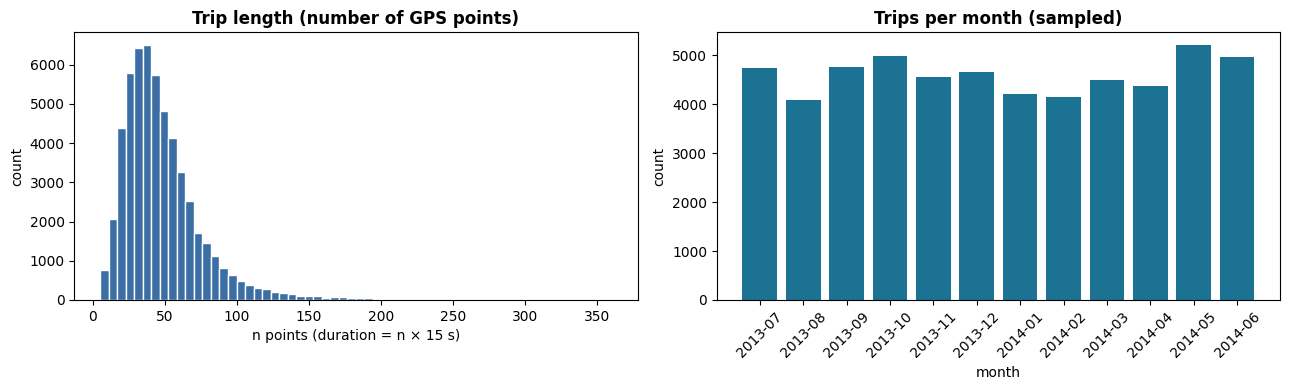

Trip length percentiles (n_points): 5% = 16, median = 42, 95% = 102
In seconds:                         5% = 240s, median = 630s, 95% = 1530s


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# (a) trip length distribution (in points; duration = n_points * 15 sec)
axes[0].hist(df["n_points"], bins=60, color="#3b6ea5", edgecolor="white")
axes[0].set_title("Trip length (number of GPS points)", fontweight="bold")
axes[0].set_xlabel("n points (duration = n × 15 s)")
axes[0].set_ylabel("count")

# (b) trips per month
df["month"] = pd.to_datetime(df["TIMESTAMP"], unit="s").dt.to_period("M").astype(str)
monthly = df["month"].value_counts().sort_index()
axes[1].bar(monthly.index, monthly.values, color="#1C7293")
axes[1].set_title("Trips per month (sampled)", fontweight="bold")
axes[1].set_xlabel("month")
axes[1].set_ylabel("count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# print percentiles for the report
pcts = df["n_points"].quantile([0.05, 0.5, 0.95]).round().astype(int)
print(f"Trip length percentiles (n_points): 5% = {pcts[0.05]}, median = {pcts[0.5]}, 95% = {pcts[0.95]}")
print(f"In seconds:                         5% = {pcts[0.05]*15}s, median = {pcts[0.5]*15}s, 95% = {pcts[0.95]*15}s")

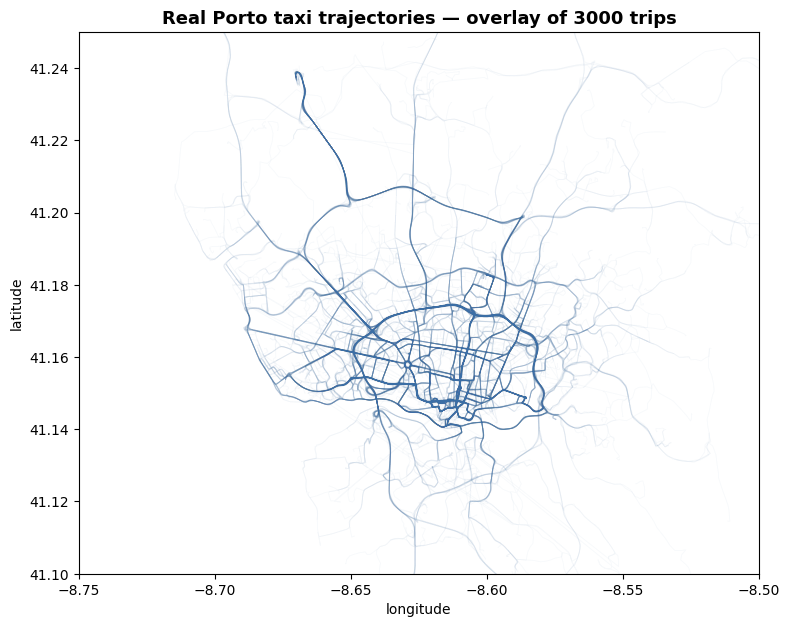

Saved figure to /content/drive/MyDrive/ADM_project/fig_overlay_real.png


In [12]:
# Overlay of real Porto trajectories — this figure goes in the slides
fig, ax = plt.subplots(figsize=(8, 7))
sample = df.sample(min(3000, len(df)), random_state=42)
for arr in sample["pts"].values:
    a = np.array(arr)
    ax.plot(a[:, 0], a[:, 1], color="#3b6ea5", alpha=0.04, linewidth=0.6)
ax.set_xlim(-8.75, -8.50)
ax.set_ylim(41.10, 41.25)
ax.set_aspect(1 / np.cos(np.deg2rad(41.16)))
ax.set_title(f"Real Porto taxi trajectories — overlay of {len(sample)} trips",
             fontsize=13, fontweight="bold")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
plt.tight_layout()
plt.savefig(FIG_PATH, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved figure to {FIG_PATH}")

You should see the real Porto road network emerge from the overlay — much more recognizable than the synthetic data. **Download this figure** and use it to replace `fig_overlay.png` in the slides.

---## 6. Save the cleaned sample to DriveSave the cleaned sample as a CSV. We drop the temporary helper columns (`pts`, `n_points`, `month`) but keep `POLYLINE` as the original JSON string — that way the existing `load_polylines()` function from the previous script can read this file with no changes.

In [13]:
keep_cols = ["TRIP_ID", "CALL_TYPE", "TAXI_ID", "TIMESTAMP",
             "DAY_TYPE", "MISSING_DATA", "POLYLINE"]
df[keep_cols].to_csv(CLEAN_PATH, index=False)

file_size_mb = os.path.getsize(CLEAN_PATH) / 1024 / 1024
print(f"Saved {len(df)} trips to {CLEAN_PATH}")
print(f"File size: {file_size_mb:.1f} MB")

Saved 55160 trips to /content/drive/MyDrive/ADM_project/porto_clean.csv
File size: 58.9 MB


---## 7. Verify reload — make sure the next notebook can read thisQuick sanity check: reload the cleaned file and parse one polyline. If this works, we're done.

In [14]:
def load_polylines(csv_path, max_trips=None):
    d = pd.read_csv(csv_path)
    polylines = []
    for s in d["POLYLINE"].values[:max_trips]:
        arr = np.array(json.loads(s))
        if len(arr) >= 5:
            polylines.append(arr)
    return polylines

trips = load_polylines(CLEAN_PATH, max_trips=5)
print(f"Reloaded {len(trips)} trips successfully")
print(f"First trip shape: {trips[0].shape}  (rows = points, cols = [lon, lat])")
print(f"First 3 points of trip 0:")
for p in trips[0][:3]:
    print(" ", p)

Reloaded 5 trips successfully
First trip shape: (11, 2)  (rows = points, cols = [lon, lat])
First 3 points of trip 0:
  [-8.611065 41.149431]
  [-8.611209 41.149368]
  [-8.611236 41.148243]


---## Done.We now have a clean sample of real Porto trajectories ready for the baseline notebook.**Recap for the report:**- Started from 1.7M real trips → randomly sampled every 30th to get a manageable subset spread across the year.- Filtered out: trips with `MISSING_DATA = True`, empty polylines, trips shorter than 5 points or longer than 360 points (we set the upper cap to avoid meter-left-on outliers dominating).- Final sample saved as `porto_clean.csv` in the project Drive folder.**Next notebook (`02_baseline.ipynb`):** extract hand-crafted features per trip, run Isolation Forest, and set up the evaluation framework with synthetic anomaly injection.